##Business Problem

Pricing strategy is one of the most critical decisions in short-term rental marketplaces.

Overpricing reduces occupancy.
Underpricing reduces revenue potential.

This project aims to build a machine learning model capable of predicting the optimal daily price of Airbnb listings based on:

*   Property characteristics
*   Host performance metrics
*   Location data
*   Reviews and ratings

The goal is to understand which factors drive pricing and how accurately price can be predicted using data.

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
from tkinter import Tk
from tkinter.filedialog import askopenfilename

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
df = pd.read_csv('/content/drive/MyDrive/AirBnB analytics/25.11_Base_de_Datos_-_AirBnB.csv', sep=";", encoding="latin1")

In [6]:
df.shape

(27075, 25)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27075 entries, 0 to 27074
Data columns (total 25 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   ï»¿ID                                           27075 non-null  object 
 1   Nombre                                          27075 non-null  object 
 2   Anfitrion                                       27069 non-null  object 
 3   Barrio                                          27075 non-null  object 
 4   Latitud                                         27075 non-null  object 
 5   Longitud                                        27075 non-null  object 
 6   Tipo de HabitaciÃ³n                             27075 non-null  object 
 7   Noches MÃ­nimas                                 27075 non-null  int64  
 8   NÃºmero de Reviews                              27075 non-null  int64  
 9   Reviews Mensuales Promedio             

In [8]:
df["Precio Diario"] = (
    df["Precio Diario"]
    .replace("[\$,]", "", regex=True)
    .astype(float)
)

<>:3: SyntaxWarning: invalid escape sequence '\$'
<>:3: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-130574664.py:3: SyntaxWarning: invalid escape sequence '\$'
  .replace("[\$,]", "", regex=True)


In [9]:
df["Tasa de Respuesta"] = (
    df["Tasa de Respuesta"]
    .astype(str)
    .str.replace("%", "")
    .astype(float)
)

df["Tasa de AceptaciÃ³n"] = (
    df["Tasa de AceptaciÃ³n"]
    .astype(str)
    .str.replace("%", "")
    .astype(float)
)

In [10]:
df.isnull().sum().sort_values(ascending=False)

,0
Tiempo de Respuesta,1610
Tasa de Respuesta,1610
Tasa de AceptaciÃ³n,1117
Rating General,82
Habitaciones,24
BaÃ±os,6
Camas,6
Anfitrion,6
Rating PrecisiÃ³n,1
NÃºmero de Reviews,0


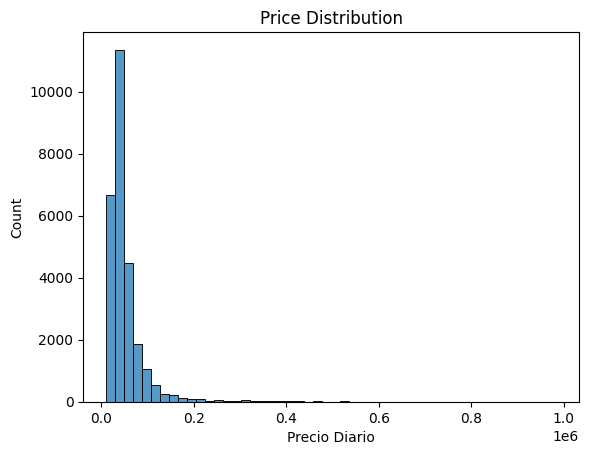

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df["Precio Diario"], bins=50)
plt.title("Price Distribution")
plt.show()

In [12]:
df["Precio Log"] = np.log1p(df["Precio Diario"])

In [13]:
df["Precio Diario"].skew()

np.float64(6.662150697480676)

In [14]:
import numpy as np

df["Precio Log"] = np.log1p(df["Precio Diario"])

In [15]:
df["Precio Log"].skew()

np.float64(1.0165651899256978)

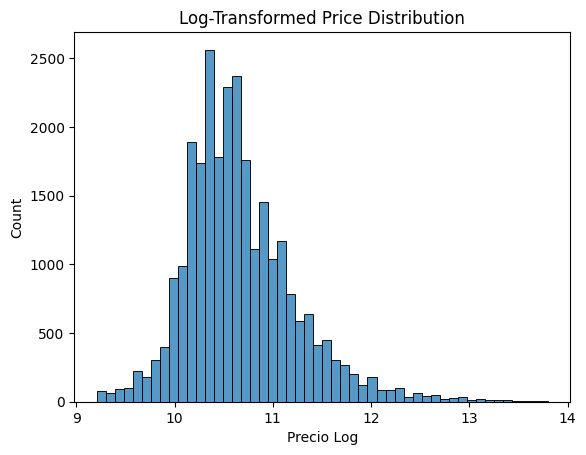

In [16]:
plt.figure()
sns.histplot(df["Precio Log"], bins=50)
plt.title("Log-Transformed Price Distribution")
plt.show()

In [17]:
y = df["Precio Log"]

In [18]:
df_model = df.drop(columns=[
    "Precio Diario",
    "Precio Log",
    "ï»¿ID",
    "Nombre",
    "Anfitrion"
])

In [19]:
df_model.isnull().sum().sort_values(ascending=False)

,0
Tasa de Respuesta,1610
Tiempo de Respuesta,1610
Tasa de AceptaciÃ³n,1117
Rating General,82
Habitaciones,24
BaÃ±os,6
Camas,6
Rating PrecisiÃ³n,1
Noches MÃ­nimas,0
Barrio,0


In [20]:
columns_to_convert_to_numeric = [
    "Latitud",
    "Longitud",
    "Reviews Mensuales Promedio",
    "BaÃ±os",
    "Rating General",
    "Rating PrecisiÃ³n",
    "Rating Limpieza",
    "Rating Check In",
    "Rating ComunicaciÃ³n",
    "Rating LocalizaciÃ³n"
]

for col in columns_to_convert_to_numeric:
    if col in df_model.columns and df_model[col].dtype == 'object':
        # Replace comma with dot for decimal separator and then convert to numeric
        df_model[col] = df_model[col].astype(str).str.replace(",", ".", regex=False)
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# Fill NaNs for numeric columns with their median
# Select numeric columns again after potential type conversions
numeric_cols = df_model.select_dtypes(include=np.number).columns
for col in numeric_cols:
    if df_model[col].isnull().any():
        median_val = df_model[col].median()
        df_model[col] = df_model[col].fillna(median_val)

# Fill remaining NaNs (which should now only be in true object/categorical columns) with "Unknown"
df_model = df_model.fillna("Unknown")

In [21]:
numeric_features = df_model.select_dtypes(include=["int64", "float64"]).columns
categorical_features = df_model.select_dtypes(include=["object"]).columns

In [22]:
numeric_features
categorical_features

Index(['Barrio', 'Tipo de HabitaciÃ³n', 'Tiempo de Respuesta'], dtype='object')

In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    df_model, y, test_size=0.2, random_state=42
)

In [24]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

In [25]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

y_pred_lr = lr_pipeline.predict(X_test)

print("Linear Regression Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression Results:
MAE: 0.319873948267645
RMSE: 0.4462981478984672
R2: 0.3614593542913095


In [26]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

rf_pipeline.fit(X_train, y_train)

y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Results:")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest Results:
MAE: 0.26919417803624973
RMSE: 0.36938539134905196
R2: 0.5625808327560553


In [27]:
# Obtener modelo entrenado
rf_model = rf_pipeline.named_steps["model"]

# Obtener nombres de columnas transformadas
feature_names = rf_pipeline.named_steps["preprocessor"].get_feature_names_out()

# Importancias
importances = rf_model.feature_importances_

# Crear DataFrame
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

importance_df.head(15)

,feature,importance
10,num__Habitaciones,0.232411
9,num__BaÃ±os,0.131630
0,num__Latitud,0.073166
1,num__Longitud,0.072895
67,cat__Tipo de HabitaciÃ³n_Vivienda Completa,0.056777
4,num__Reviews Mensuales Promedio,0.047877
5,num__NÃºmero de Publicaciones del Host en la C...,0.040045
6,num__Reviews 12MM,0.036474
3,num__NÃºmero de Reviews,0.029834
2,num__Noches MÃ­nimas,0.029232


In [28]:
!pip install shap

In [29]:
import shap

rf_model = rf_pipeline.named_steps["model"]
preprocessor = rf_pipeline.named_steps["preprocessor"]

X_train_transformed = preprocessor.transform(X_train)

# Convertir a array denso si es sparse
if hasattr(X_train_transformed, "toarray"):
    X_train_transformed = X_train_transformed.toarray()

# Asegurar tipo float
X_train_transformed = X_train_transformed.astype(float)

In [30]:
import numpy as np

sample_size = 300  # 200-500 es ideal
idx = np.random.choice(X_train_transformed.shape[0], sample_size, replace=False)

X_sample = X_train_transformed[idx]

In [31]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_sample)

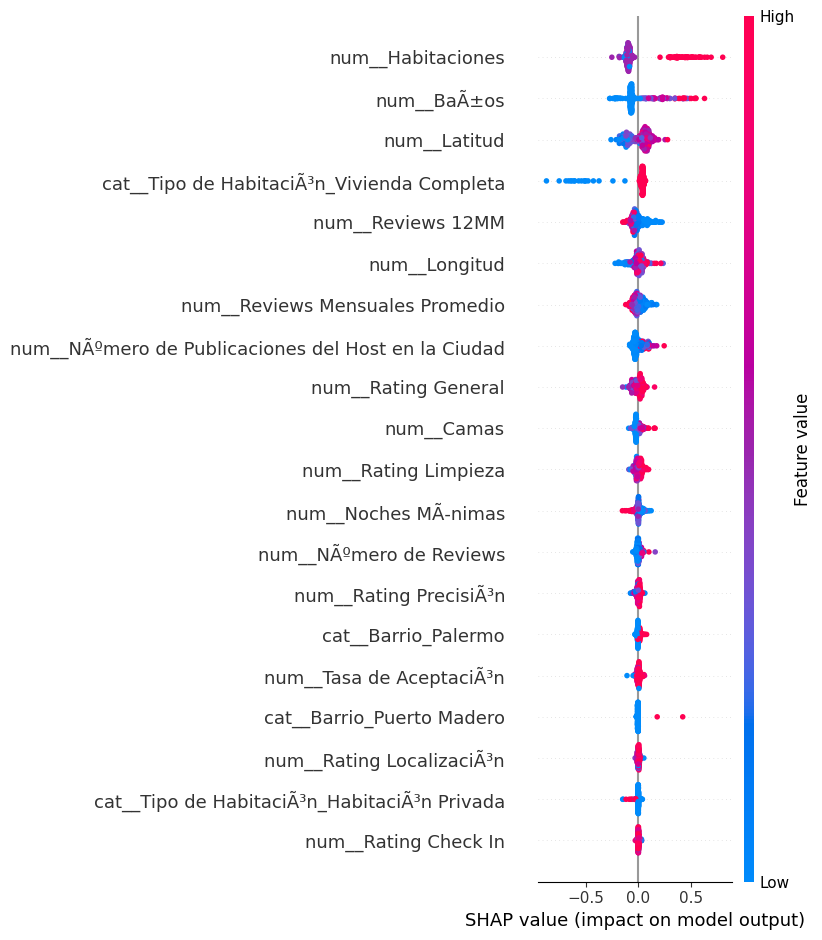

In [32]:
shap.summary_plot(shap_values, X_sample, feature_names=feature_names)